# SQL queries

Reusable SQL and helpers against the project database (`project_config`: `DATA_DIR` / `DB_FILENAME`, usually `data/raw/events.db`). **Run the setup cell first.**

Table reference: [`docs/DB_SCHEMA.md`](../docs/DB_SCHEMA.md).

## `author_association` (GitHub)

The project reads the first non-empty of `payload.comment`, `payload.review`, `payload.pull_request`, or `payload.issue` (`author_association` lives on whichever object applies). Values match GitHub’s **`CommentAuthorAssociation`** enum (REST / webhooks / GraphQL)—see [GitHub docs](https://docs.github.com/en/graphql/reference/enums#commentauthorassociation).

| Value | Meaning (GitHub) |
|---|---|
| **`OWNER`** | Owner of the repository. |
| **`MEMBER`** | Member of the organization that owns the repository. |
| **`COLLABORATOR`** | Invited to collaborate on the repository. |
| **`CONTRIBUTOR`** | Has previously committed to the repository. |
| **`FIRST_TIMER`** | Has not previously committed on GitHub. |
| **`FIRST_TIME_CONTRIBUTOR`** | Has not previously committed to this repository. |
| **`NONE`** | No association with the repository. |
| **`MANNEQUIN`** | Placeholder for an unclaimed / imported user. |

Your dumps may omit some of these entirely. Empty or missing JSON yields `(empty)` in segmentation helpers.

## `type` (GitHub event)

Top-level **`$.type`** is the GitHub timeline / webhook event name (same strings as `json_extract(event_data, '$.type')`). Full detail: [`docs/DB_SCHEMA.md`](../docs/DB_SCHEMA.md) — *Meaning of top-level `type`*.

| Value | Meaning (short) |
|---|---|
| **`PullRequestEvent`** | PR lifecycle activity (open, close, edit, label, sync, …); payload focuses on **`pull_request`**. |
| **`PullRequestReviewEvent`** | A PR **review** submitted (approve / request changes / review-level comment); **`review`**. |
| **`PullRequestReviewCommentEvent`** | **Inline** comment on a **line** of the PR diff; **`comment`**. |
| **`IssueCommentEvent`** | **Thread** comment on an issue or PR (PRs are issues); **`comment`**. |

Other `type` strings are possible if you widen extraction. Missing/blank yields `(missing)` in segmentation helpers.

## Segmentations: **repo** × **author_association**, **repo** × **event type**, **event type**

Under each of `events` / `cleaned` / `scores`, the **Segmentations** code cell calls `run_breakdowns_for_scope(scope)`, which shows: (1) **`breakdown_repo_author_association`** — `owner/repo` × **author_association**; (2) **`breakdown_repo_event_type`** — `owner/repo` × **`$.type`**; (3) **`breakdown_event_type`** — marginal counts by **`$.type`**. There is **no** programming-language / “repo style” bucket.

| `scope` | Row set |
|---------|--------|
| `"events"` | All rows in `events` |
| `"cleaned"` | `cleaned` inner join `events` (preprocess survivors) |
| `"scores"` | `scores` join `cleaned` join `events` (one row per judge model per comment) |

The setup cell leaves those calls **commented out** by default; uncomment to run.


In [386]:
import json
import sys
from html import escape
from pathlib import Path

import pandas as pd
import sqlite3
from IPython.display import HTML, Markdown, display

# --- configurable sample for deep JSON inspection ---
# Set to a specific GitHub event id string, or None to use the first row in `events`.
SAMPLE_EVENT_ID: str | None = 34516188931

# How much text to show in SQL previews (table peek cells).
EVENT_DATA_PREVIEW_LEN = 200
CLEANED_TEXT_PREVIEW_LEN = 220
TOKENS_PREVIEW_LEN = 140
REASONING_PREVIEW_LEN = 160


def _repo_root_for_notebook() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "project_config.py").is_file():
            return p
    return here


_REPO = _repo_root_for_notebook()
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from project_config import DATA_DIR, DB_FILENAME, repo_root

DB_PATH = repo_root() / DATA_DIR / DB_FILENAME

def author_association_sql(alias: str = "e") -> str:
    """Same paths as `preprocessing.workflow._get_author_association` / `judge/storage.CLEANED_JOIN_FILTERS`."""
    return (
        f"COALESCE("
        f"json_extract({alias}.event_data, '$.payload.comment.author_association'), "
        f"json_extract({alias}.event_data, '$.payload.review.author_association'), "
        f"json_extract({alias}.event_data, '$.payload.pull_request.author_association'), "
        f"json_extract({alias}.event_data, '$.payload.issue.author_association')"
        f")"
    )



def repo_name_sql(alias: str = "e") -> str:
    return f"json_extract({alias}.event_data, '$.repo.name')"


def event_type_sql(alias: str = "e") -> str:
    """Top-level GitHub / GHArchive event type (e.g. ``IssueCommentEvent``)."""
    return f"json_extract({alias}.event_data, '$.type')"


def comment_author_login_sql(alias: str = "e") -> str:
    """GitHub login for comment/review author; falls back to ``actor.login``."""
    return (
        f"COALESCE("
        f"json_extract({alias}.event_data, '$.payload.comment.user.login'), "
        f"json_extract({alias}.event_data, '$.payload.review.user.login'), "
        f"json_extract({alias}.event_data, '$.actor.login')"
        f")"
    )


# SQL FROM clause + join pattern per logical table (always expose `events` as `e` for JSON paths).
_BREAKDOWN_FROM = {
    "events": "FROM events e",
    "cleaned": "FROM cleaned c INNER JOIN events e ON e.id = c.id",
    "scores": (
        "FROM scores s "
        "INNER JOIN cleaned c ON c.id = s.comment_id "
        "INNER JOIN events e ON e.id = c.id"
    ),
}


def breakdown_df(
    scope: str,
    select_exprs: list[tuple[str, str]],
    group_by_positions: str,
    order_by: str = "n DESC",
) -> pd.DataFrame:
    """Run a grouped COUNT(*) query for scope in {'events','cleaned','scores'}.

    Use SQLite ``GROUP BY 1`` / ``GROUP BY 1, 2`` so grouping matches SELECT aliases.
    """
    if scope not in _BREAKDOWN_FROM:
        raise ValueError(f"scope must be one of {list(_BREAKDOWN_FROM)}")
    cols = ", ".join(f"{expr} AS {alias}" for expr, alias in select_exprs)
    q = f"""
    SELECT {cols}, COUNT(*) AS n
    {_BREAKDOWN_FROM[scope]}
    GROUP BY {group_by_positions}
    ORDER BY {order_by}
    """
    with connect() as conn:
        return pd.read_sql_query(q, conn)


def breakdown_repo_author_association(scope: str = "cleaned") -> pd.DataFrame:
    """Counts by full `owner/repo` (`$.repo.name`) × author_association."""
    rn = repo_name_sql("e")
    aa = author_association_sql("e")
    aa_label = f"COALESCE(NULLIF(TRIM({aa}), ''), '(empty)')"
    return breakdown_df(
        scope,
        [(rn, "repo"), (aa_label, "author_association")],
        "1, 2",
        order_by="repo ASC, author_association ASC, n DESC",
    )


def breakdown_event_type(scope: str = "cleaned") -> pd.DataFrame:
    """Counts by GH event ``type`` (``json_extract(..., '$.type')``)."""
    et = event_type_sql("e")
    type_label = f"COALESCE(NULLIF(TRIM({et}), ''), '(missing)')"
    return breakdown_df(
        scope,
        [(type_label, "event_type")],
        "1",
        order_by="n DESC, event_type ASC",
    )


def breakdown_repo_event_type(scope: str = "cleaned") -> pd.DataFrame:
    """Counts by full `owner/repo` (`$.repo.name`) × GH event `type` (`$.type`)."""
    rn = repo_name_sql("e")
    et = event_type_sql("e")
    repo_col = f"COALESCE(NULLIF(TRIM({rn}), ''), '(missing)')"
    type_label = f"COALESCE(NULLIF(TRIM({et}), ''), '(missing)')"
    return breakdown_df(
        scope,
        [(repo_col, "repo"), (type_label, "event_type")],
        "1, 2",
        order_by="repo ASC, event_type ASC, n DESC",
    )


pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", None)


def connect() -> sqlite3.Connection:
    return sqlite3.connect(str(DB_PATH))


def show_sample_event() -> None:
    """Pretty-print one row's `event_data` JSON in a scrollable panel."""
    with connect() as conn:
        if SAMPLE_EVENT_ID:
            row = conn.execute(
                "SELECT id, event_data FROM events WHERE id = ? LIMIT 1",
                (SAMPLE_EVENT_ID,),
            ).fetchone()
        else:
            row = conn.execute("SELECT id, event_data FROM events LIMIT 1").fetchone()
    if not row:
        display(Markdown("_No rows in `events`._"))
        return
    eid, raw = row
    try:
        pretty = json.dumps(json.loads(raw), indent=2, ensure_ascii=False)
    except json.JSONDecodeError:
        pretty = raw[:8000] + ("\n… [truncated]" if len(raw) > 8000 else "")
    display(Markdown(f"##### One sample `event_data` (`id={eid}`)"))
    safe = escape(pretty)
    html = (
        "<div style=\"max-height:28rem;overflow:auto;border:1px solid #ccc;"
        "padding:0.6rem;background:#f9f9f9;font-family:ui-monospace,monospace\">"
        f"<pre style=\"margin:0;white-space:pre-wrap;font-size:12px;line-height:1.35\">{safe}</pre>"
        "</div>"
    )
    display(HTML(html))


def peek_table(name: str, *, display_top_n: int = 2) -> None:
    """Row count (plus per-repo for `events` / `cleaned` / `scores`), PRAGMA layout, samples."""
    n = max(1, min(int(display_top_n), 50_000))
    with connect() as conn:
        display(Markdown("##### Row count"))
        display(pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {name}", conn))
        if name in ("events", "cleaned", "scores"):
            display(Markdown("##### Row count by repo (`$.repo.name`)"))
            rn = repo_name_sql("e")
            repo_col = f"COALESCE(NULLIF(TRIM({rn}), ''), '(missing)')"
            if name == "events":
                q_repo = f"""
                SELECT {repo_col} AS repo, COUNT(*) AS n
                FROM events e
                GROUP BY 1
                ORDER BY n DESC, repo ASC
                """
            elif name == "cleaned":
                q_repo = f"""
                SELECT {repo_col} AS repo, COUNT(*) AS n
                FROM cleaned c INNER JOIN events e ON e.id = c.id
                GROUP BY 1
                ORDER BY n DESC, repo ASC
                """
            else:
                q_repo = f"""
                SELECT {repo_col} AS repo, COUNT(*) AS n
                FROM scores s
                INNER JOIN cleaned c ON c.id = s.comment_id
                INNER JOIN events e ON e.id = c.id
                GROUP BY 1
                ORDER BY n DESC, repo ASC
                """
            display(pd.read_sql_query(q_repo, conn))
        display(Markdown("##### Columns"))
        display(pd.read_sql_query(f"PRAGMA table_info({name})", conn))
        display(Markdown(f"##### Sample ({n} rows, truncated previews)"))
        if name == "events":
            q = (
                f"SELECT id, substr(event_data, 1, {EVENT_DATA_PREVIEW_LEN}) || '…' AS event_data_preview "
                f"FROM events LIMIT {n}"
            )
        elif name == "cleaned":
            q = (
                "SELECT id, "
                f"substr(cleaned_text, 1, {CLEANED_TEXT_PREVIEW_LEN}) || '…' AS cleaned_text_preview, "
                f"substr(tokens, 1, {TOKENS_PREVIEW_LEN}) || '…' AS tokens_preview "
                f"FROM cleaned LIMIT {n}"
            )
        elif name == "scores":
            q = (
                "SELECT comment_id, model_name, "
                "fun_score, nsi_score, insi_score, isi_score, "
                f"substr(fun_reasoning, 1, {REASONING_PREVIEW_LEN}) || '…' AS fun_reasoning_preview, "
                f"substr(nsi_reasoning, 1, {REASONING_PREVIEW_LEN}) || '…' AS nsi_reasoning_preview, "
                f"substr(insi_reasoning, 1, {REASONING_PREVIEW_LEN}) || '…' AS insi_reasoning_preview, "
                f"substr(isi_reasoning, 1, {REASONING_PREVIEW_LEN}) || '…' AS isi_reasoning_preview "
                f"FROM scores LIMIT {n}"
            )
        else:
            q = f"SELECT * FROM {name} LIMIT {n}"
        display(pd.read_sql_query(q, conn))




def run_breakdowns_for_scope(scope: str) -> None:
    """For one scope: repo × aa, repo × event type, then marginal counts by ``$.type``."""
    with connect() as conn:
        tables = {r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'")}
    if scope == "scores" and "scores" not in tables:
        display(Markdown(f"*Scope `{scope}`: table `scores` missing — run the judge.*"))
        return
    if scope == "cleaned" and "cleaned" not in tables:
        display(Markdown(f"*Scope `{scope}`: table `cleaned` missing.*"))
        return
    prev_max = pd.get_option("display.max_rows")
    try:
        pd.set_option("display.max_rows", 150)
        display(Markdown("**Repo × author_association** — `$.repo.name` (full repo, not a language bucket)"))
        display(breakdown_repo_author_association(scope))
        display(Markdown("**Repo × event type** — `$.repo.name` × top-level `$.type`"))
        display(breakdown_repo_event_type(scope))
        display(Markdown("**Event type** — marginal counts on top-level `$.type`"))
        display(breakdown_event_type(scope))
    finally:
        pd.set_option("display.max_rows", prev_max)


def run_all_breakdowns(
    scopes: tuple[str, ...] = ("events", "cleaned", "scores"),
) -> None:
    """Optional: run `run_breakdowns_for_scope` for every table scope."""
    for scope in scopes:
        run_breakdowns_for_scope(scope)


SCORE_COLUMNS: tuple[str, ...] = ("fun_score", "nsi_score", "insi_score", "isi_score")

# Preview length for scrollable samples of all-zero-score rows in ``show_score_stats``.
ALL_ZERO_COMMENT_PREVIEW_CHARS = 600


def all_zero_scores_mask(df: pd.DataFrame) -> pd.Series:
    """True where ``FUN``, ``NSI``, ``INSI``, and ``ISI`` are all exactly 0."""
    return (
        (df["fun_score"] == 0)
        & (df["nsi_score"] == 0)
        & (df["insi_score"] == 0)
        & (df["isi_score"] == 0)
    )


def load_scores_with_metadata(*, include_cleaned_text: bool = False) -> pd.DataFrame:
    """``scores`` joined to ``events`` (via ``cleaned``). One row per (``comment_id``, ``model_name``).

    Set ``include_cleaned_text=True`` when you need comment text (e.g. samples of all-zero rows).
    """
    rn = repo_name_sql("e")
    aa = author_association_sql("e")
    ul = comment_author_login_sql("e")
    et = event_type_sql("e")
    repo_col = f"COALESCE(NULLIF(TRIM({rn}), ''), '(missing)')"
    aa_label = f"COALESCE(NULLIF(TRIM({aa}), ''), '(empty)')"
    user_col = f"COALESCE(NULLIF(TRIM({ul}), ''), '(missing)')"
    type_col = f"COALESCE(NULLIF(TRIM({et}), ''), '(missing)')"
    text_col = ", c.cleaned_text AS cleaned_text" if include_cleaned_text else ""
    q = f"""
    SELECT
      s.comment_id,
      s.model_name,
      s.fun_score,
      s.nsi_score,
      s.insi_score,
      s.isi_score,
      {repo_col} AS repo,
      {aa_label} AS author_association,
      {user_col} AS user_login,
      {type_col} AS event_type
      {text_col}
    FROM scores s
    INNER JOIN cleaned c ON c.id = s.comment_id
    INNER JOIN events e ON e.id = c.id
    """
    with connect() as conn:
        return pd.read_sql_query(q, conn)


def score_stats_grouped(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """Per group: ``n_rows``, per score column ``_n`` and ``_avg``/``_mean``/``_median``/``_p25`` … ``_p99``."""
    rows: list[dict[str, object]] = []
    for keys, g in df.groupby(group_cols, dropna=False):
        keys_t = keys if isinstance(keys, tuple) else (keys,)
        row = {group_cols[i]: keys_t[i] for i in range(len(group_cols))}
        row["n_rows"] = len(g)
        for c in SCORE_COLUMNS:
            s = g[c].dropna()
            row[f"{c}_n"] = int(s.shape[0])
            if s.empty:
                nan = float("nan")
                for suffix in (
                    "avg",
                    "mean",
                    "median",
                    "p25",
                    "p50",
                    "p75",
                    "p99",
                ):
                    row[f"{c}_{suffix}"] = nan
            else:
                mean = float(s.mean())
                row[f"{c}_avg"] = mean
                row[f"{c}_mean"] = mean
                row[f"{c}_median"] = float(s.median())
                row[f"{c}_p25"] = float(s.quantile(0.25))
                row[f"{c}_p50"] = float(s.quantile(0.50))
                row[f"{c}_p75"] = float(s.quantile(0.75))
                row[f"{c}_p99"] = float(s.quantile(0.99))
        rows.append(row)
    out = pd.DataFrame(rows)
    return out.sort_values(group_cols, kind="mergesort").reset_index(drop=True)


def score_stats_by_repo(
    df: pd.DataFrame | None = None, *, exclude_all_zero: bool = False
) -> pd.DataFrame:
    """FUN/NSI/INSI/ISI summaries grouped by ``repo`` only.

    Pass ``df`` to reuse a frame (e.g. after excluding all-zero rows). If ``df`` is
    ``None`` and ``exclude_all_zero=True``, loads scores and drops rows where all
    four dimensions are 0.
    """
    if df is None:
        df = load_scores_with_metadata()
        if exclude_all_zero:
            df = df.loc[~all_zero_scores_mask(df)].copy()
    return score_stats_grouped(df, ["repo"])


def score_stats_by_repo_author_association(
    df: pd.DataFrame | None = None, *, exclude_all_zero: bool = False
) -> pd.DataFrame:
    """Summaries grouped by ``repo`` × ``author_association``."""
    if df is None:
        df = load_scores_with_metadata()
        if exclude_all_zero:
            df = df.loc[~all_zero_scores_mask(df)].copy()
    return score_stats_grouped(df, ["repo", "author_association"])


def score_stats_by_repo_event_type(
    df: pd.DataFrame | None = None, *, exclude_all_zero: bool = False
) -> pd.DataFrame:
    """Summaries grouped by ``repo`` × ``event_type`` (top-level ``$.type``)."""
    if df is None:
        df = load_scores_with_metadata()
        if exclude_all_zero:
            df = df.loc[~all_zero_scores_mask(df)].copy()
    return score_stats_grouped(df, ["repo", "event_type"])


def score_stats_by_repo_aa_user(
    df: pd.DataFrame | None = None, *, exclude_all_zero: bool = False
) -> pd.DataFrame:
    """Summaries grouped by ``repo`` × ``author_association`` × ``user_login``."""
    if df is None:
        df = load_scores_with_metadata()
        if exclude_all_zero:
            df = df.loc[~all_zero_scores_mask(df)].copy()
    return score_stats_grouped(df, ["repo", "author_association", "user_login"])


def score_stats_by_repo_aa_user_event_type(
    df: pd.DataFrame | None = None, *, exclude_all_zero: bool = False
) -> pd.DataFrame:
    """Summaries grouped by ``repo`` × ``author_association`` × ``user_login`` × ``$.type``."""
    if df is None:
        df = load_scores_with_metadata()
        if exclude_all_zero:
            df = df.loc[~all_zero_scores_mask(df)].copy()
    return score_stats_grouped(
        df,
        ["repo", "author_association", "user_login", "event_type"],
    )


def display_all_zero_score_comment_samples(
    df: pd.DataFrame, *, limit: int = 500, preview_chars: int = ALL_ZERO_COMMENT_PREVIEW_CHARS
) -> None:
    """Scrollable panel of truncated ``cleaned_text`` for rows with all-zero scores (up to ``limit``, max 500)."""
    if "cleaned_text" not in df.columns:
        return
    sub = df.loc[all_zero_scores_mask(df)].copy()
    if sub.empty:
        return
    cap = max(1, min(int(limit), 500))
    sub = sub.head(cap)
    chunks: list[str] = []
    for _, r in sub.iterrows():
        raw = str(r.get("cleaned_text") or "")
        preview = raw[:preview_chars] + ("…" if len(raw) > preview_chars else "")
        chunks.append(
            f"comment_id={r.get('comment_id')}  model={r.get('model_name')}  "
            f"repo={r.get('repo')}\n{preview}\n{'-' * 60}\n"
        )
    body = escape("".join(chunks))
    html = (
        '<div style="max-height:48rem;overflow:auto;border:1px solid #ccc;'
        'padding:0.6rem;background:#f9f9f9;font-family:ui-monospace,monospace">'
        f'<pre style="margin:0;white-space:pre-wrap;font-size:12px;line-height:1.35">{body}</pre>'
        "</div>"
    )
    display(HTML(html))


def display_dataframe_scrollable(
    df: pd.DataFrame, *, max_height: str = "32rem"
) -> None:
    """HTML table in a scrollable panel (wide/tall grouped score stats)."""
    html = df.to_html(classes=("dataframe",), border=0, escape=True, max_rows=None)
    display(
        HTML(
            f'<div style="max-height:{max_height};overflow:auto;width:100%;'
            'border:1px solid #ddd;padding:0.35rem;background:#fafafa">'
            f"{html}</div>"
        )
    )


def plot_global_score_histograms_all_vs_non_full_zero(
    df: pd.DataFrame,
    *,
    compare_full_population: bool = True,
    single_figure_title: str | None = None,
) -> None:
    """Marginal **histograms** (bar counts at 0,1,2,3) per FUN/NSI/INSI/ISI.

    If ``compare_full_population`` is True, draws **two** figures: full loaded cohort vs rows
    after dropping FUN=NSI=INSI=ISI=0. If False, draws **one** figure for the dataframe passed in
    (use with already-filtered stats rows; set ``single_figure_title`` for the suptitle).
    """
    import matplotlib.pyplot as plt
    import numpy as np

    def _one_grid(data: pd.DataFrame, supt: str, bar_color: str) -> None:
        xpos = np.arange(4)
        fig, axes = plt.subplots(2, 2, figsize=(11, 9))
        fig.suptitle(supt)
        for ax, col in zip(axes.flat, SCORE_COLUMNS):
            vc = data[col].value_counts().reindex([0, 1, 2, 3], fill_value=0)
            ax.bar(
                xpos,
                vc.values.astype(int),
                width=0.62,
                color=bar_color,
                edgecolor="white",
            )
            ax.set_xticks(xpos)
            ax.set_xticklabels(["0", "1", "2", "3"])
            ax.set_title(col)
            ax.set_xlabel("ordinal score")
            ax.set_ylabel("count")
            for xi, yi in zip(xpos, vc.values):
                ax.text(xi, yi, str(int(yi)), ha="center", va="bottom", fontsize=8)
        plt.tight_layout()
        plt.show()

    d = df.drop(columns=["cleaned_text"], errors="ignore").copy()
    if d.empty:
        return
    for c in SCORE_COLUMNS:
        d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0).astype(int)

    if not compare_full_population:
        d_plot = d.loc[~all_zero_scores_mask(d)].copy()
        if d_plot.empty:
            display(Markdown("_No rows left after excluding full-zero blocks._"))
            return
        title = single_figure_title or (
            "Marginal histograms — rows below exclude FUN=NSI=INSI=ISI all zero"
        )
        _one_grid(d_plot, title, "#55a868")
        return

    mask_zero = all_zero_scores_mask(d)
    d_non = d.loc[~mask_zero].copy()
    datasets = [
        (
            d,
            "Marginal histograms — full cohort (every loaded judge row; includes blanket all-zero)",
            "#4c72b0",
        ),
        (
            d_non,
            "Marginal histograms — after removing blanket all-zero rows (FUN=NSI=INSI=ISI=0)",
            "#55a868",
        ),
    ]
    for data, supt, bar_color in datasets:
        if data.empty:
            display(
                Markdown(
                    "_No rows left after removing full-zero blocks; skipping second histogram grid._"
                )
            )
            continue
        _one_grid(data, supt, bar_color)


_EVENT_TYPE_ABBREV: dict[str, str] = {
    "IssueCommentEvent": "IssueComment",
    "PullRequestReviewCommentEvent": "PRRevComment",
    "PullRequestReviewEvent": "PRReview",
    "PullRequestEvent": "PullRequest",
    "IssuesEvent": "Issues",
    "CommitCommentEvent": "CommitComment",
    "ReleaseEvent": "Release",
    "CreateEvent": "Create",
    "ForkEvent": "Fork",
    "WatchEvent": "Watch",
}


def abbreviate_github_event_type(name: str, *, max_len: int = 26) -> str:
    """Short label for long ``$.type`` strings (axis ticks / downloads)."""
    s = str(name).strip()
    if s in _EVENT_TYPE_ABBREV:
        return _EVENT_TYPE_ABBREV[s]
    if s.endswith("Event"):
        s = s[: -len("Event")]
    if len(s) <= max_len:
        return s
    return s[: max_len - 1] + "…"


def plot_score_summaries_by_category(
    df: pd.DataFrame,
    *,
    category_col: str,
    title: str,
    max_categories: int = 48,
    include_s0: bool = True,
    one_figure_per_panel: bool = False,
    use_event_type_abbrev: bool = False,
    horizontal_event_bars: bool | None = None,
    show_event_type_label_table: bool = True,
) -> None:
    """Stacked **histogram-style** counts per ``category_col``, using only rows where **not**
    all four dimensions are 0. If ``include_s0`` is False, bars stack **s=1,2,3** only.

    Set ``one_figure_per_panel=True`` to emit **four separate figures** (FUN / NSI / INSI / ISI)
    so each can be saved individually from Jupyter. For ``event_type`` with separate figures,
    **horizontal** stacked bars default on so full ``$.type`` strings fit on the y-axis;
    margins and font size tighten automatically. Optional ``use_event_type_abbrev=True``
    swaps in short labels plus a lookup table.
    """
    import matplotlib.pyplot as plt

    d = df.drop(columns=["cleaned_text"], errors="ignore").copy()
    if d.empty or category_col not in d.columns:
        return
    for c in SCORE_COLUMNS:
        d[c] = pd.to_numeric(d[c], errors="coerce").fillna(0).astype(int)
    d = d.loc[~all_zero_scores_mask(d)].copy()
    if d.empty:
        display(Markdown(f"_No rows with any non-zero score — skip `{category_col}` breakdown plot._"))
        return
    cats_full = sorted(d[category_col].astype(str).unique())
    if len(cats_full) > max_categories:
        display(
            Markdown(
                f"_Skipping plots: `{category_col}` has {len(cats_full)} values (max {max_categories})._"
            )
        )
        return
    plot_col = category_col
    if use_event_type_abbrev and category_col == "event_type":
        d = d.copy()
        d["_plot_cat"] = d[category_col].astype(str).map(abbreviate_github_event_type)
        plot_col = "_plot_cat"
        if show_event_type_label_table:
            mapping = (
                pd.DataFrame(
                    {
                        "short_label": [abbreviate_github_event_type(x) for x in cats_full],
                        "full_event_type": cats_full,
                    }
                )
                .drop_duplicates(subset=["short_label", "full_event_type"])
                .sort_values("full_event_type")
                .reset_index(drop=True)
            )
            display(
                Markdown(
                    "**Event-type axis labels** — ``short_label`` is what appears on the chart; "
                    "``full_event_type`` is the top-level ``$.type`` string in ``events``."
                )
            )
            display(mapping)
    if horizontal_event_bars is None:
        horizontal_event_bars = bool(
            category_col == "event_type" and one_figure_per_panel
        )
    colors_full = ["#4c72b0", "#55a868", "#c44e52", "#8172b3"]
    levels = (0, 1, 2, 3) if include_s0 else (1, 2, 3)
    colors = colors_full if include_s0 else colors_full[1:]
    stack_label = "0/1/2/3" if include_s0 else "1/2/3 (s=0 omitted from stacks)"
    suffix = (
        "(full-zero judge rows excluded)"
        if include_s0
        else "(full-zero judge rows excluded; s=0 counts not stacked)"
    )

    def plot_one_ax(ax, dim_col: str, *, show_panel_title: bool = True) -> None:
        ct = pd.crosstab(d[plot_col], d[dim_col])
        for v in (0, 1, 2, 3):
            if v not in ct.columns:
                ct[v] = 0
        ct = ct[[*levels]]
        ct = ct.reindex(sorted(ct.index.astype(str))).fillna(0).astype(int)
        if include_s0:
            ct.columns = ["s=0", "s=1", "s=2", "s=3"]
        else:
            ct.columns = ["s=1", "s=2", "s=3"]
        if horizontal_event_bars and category_col == "event_type":
            ct = ct.copy()
            ct.index.name = None
        kind = "barh" if horizontal_event_bars else "bar"
        ct.plot(
            kind=kind,
            stacked=True,
            ax=ax,
            color=colors,
            width=0.82,
            legend=True,
        )
        if show_panel_title:
            ax.set_title(dim_col)
        if horizontal_event_bars:
            if category_col != "event_type":
                ax.set_ylabel(category_col)
            else:
                ax.set_ylabel("")
            ax.set_xlabel("count")
        else:
            ax.set_xlabel(category_col)
            plt.setp(ax.get_xticklabels(), rotation=52, ha="right")
        _leg_fs = 11 if horizontal_event_bars else 8
        ax.legend(
            title="ordinal",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=_leg_fs,
            title_fontsize=_leg_fs,
        )

    if one_figure_per_panel:
        nbin = int(d[plot_col].astype(str).nunique())
        maxlen = (
            max(len(str(x)) for x in cats_full)
            if category_col == "event_type"
            else 24
        )
        left_margin = float(min(0.58, max(0.22, 0.0088 * maxlen + 0.14)))
        for dim_col in SCORE_COLUMNS:
            if horizontal_event_bars:
                h = max(4.2, min(26.0, 0.34 * nbin + 2.8))
                w = max(8.2, min(11.5, 7.8 + 0.018 * maxlen))
            else:
                h = max(4.2, min(16.0, 0.22 * nbin + 3.5))
                w = 9.5
            fig, ax = plt.subplots(figsize=(w, h))
            plot_one_ax(ax, dim_col, show_panel_title=False)
            if horizontal_event_bars:
                ax.tick_params(axis="y", labelsize=7)
                plt.setp(ax.get_yticklabels(), fontsize=7)
            fig.subplots_adjust(
                left=left_margin,
                right=0.78,
                bottom=0.07,
                top=0.97,
            )
            plt.show()
        return

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(f"{title} — stacked counts at {stack_label} per {category_col} {suffix}")
    for ax, dim_col in zip(axes.flat, SCORE_COLUMNS):
        plot_one_ax(ax, dim_col, show_panel_title=True)
    plt.tight_layout()
    plt.show()


def total_score_per_row(df: pd.DataFrame) -> pd.Series:
    """Per judge row: ``fun_score + nsi_score + insi_score + isi_score`` (range 0–12)."""
    d = df.drop(columns=["cleaned_text"], errors="ignore").copy()
    total = pd.Series(0, index=d.index, dtype="int64")
    for c in SCORE_COLUMNS:
        col = (
            d[c]
            if c in d.columns
            else pd.Series(0, index=d.index, dtype="int64")
        )
        total = total + pd.to_numeric(col, errors="coerce").fillna(0).astype(int)
    return total


def total_score_by_repo_table(df: pd.DataFrame) -> pd.DataFrame:
    """One row per ``repo``: counts, sum/mean/median/std of per-row total score."""
    d = df.drop(columns=["cleaned_text"], errors="ignore").copy()
    if d.empty or "repo" not in d.columns:
        return pd.DataFrame()
    ts = total_score_per_row(d)
    out = (
        pd.DataFrame({"repo": d["repo"].astype(str), "total_score": ts})
        .groupby("repo", dropna=False)
        .agg(
            n_rows=("total_score", "count"),
            sum_total_score=("total_score", "sum"),
            mean_total_score=("total_score", "mean"),
            median_total_score=("total_score", "median"),
            std_total_score=("total_score", "std"),
        )
        .reset_index()
        .sort_values("repo", kind="mergesort")
        .reset_index(drop=True)
    )
    return out


def plot_total_score_by_repo(df: pd.DataFrame, *, title_prefix: str = "") -> None:
    """Bar chart: mean per-row total score (FUN+NSI+INSI+ISI) by ``repo``."""
    import matplotlib.pyplot as plt

    tbl = total_score_by_repo_table(df)
    if tbl.empty:
        return
    w = max(9.0, min(28.0, 0.42 * len(tbl) + 6.0))
    fig, ax = plt.subplots(figsize=(w, 5.2))
    repos = tbl["repo"].astype(str)
    x = range(len(tbl))
    mean_y = tbl["mean_total_score"].to_numpy(dtype=float, copy=False)
    ax.bar(x, mean_y, color="#4c72b0", edgecolor="white")
    ax.set_xticks(list(x))
    ax.set_xticklabels(repos)
    ax.set_ylabel("mean total score")
    ax.set_ylim(0, 12)
    ax.set_xlabel("repo")
    pref = (title_prefix + " — ") if title_prefix else ""
    ax.set_title(f"{pref}Mean total score per judge row (max 12)")
    plt.setp(ax.get_xticklabels(), rotation=52, ha="right")
    fig.tight_layout()
    plt.show()


def show_score_stats(
    which: str = "both",
    *,
    exclude_all_zero: bool = False,
    all_zero_sample_limit: int = 500,
    show_plots: bool = False,
) -> None:
    """Print wide tables. ``which``: ``repo`` | ``repo_aa`` | ``repo_type`` | ``repo_aa_user`` | ``repo_aa_user_type`` | ``both`` | ``all``.

    Set ``exclude_all_zero=True`` to report how many rows have FUN=NSI=INSI=ISI=0, show
    scrollable comment samples for those rows, then run the same breakdowns on the rest.

    Set ``show_plots=True`` for marginal **histograms** (counts at 0–3). With
    ``exclude_all_zero=False`` you get a **two-panel** comparison (full cohort vs after removing
    blanket all-zero rows). With ``exclude_all_zero=True`` the global plot matches the **same
    filtered rows** as the tables. Stacked breakdowns by **repo** and **event type** always use
    the non–blanket-all-zero subset (requires ``matplotlib``). The **repo** section also prints
    a **total score** table (sum of four ordinals per row, partitioned by repo) and, with
    ``show_plots``, a bar chart of mean total score by repo.
    """
    with connect() as conn:
        tables = {r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'")}
    if "scores" not in tables:
        display(Markdown("_No ``scores`` table — run the judge._"))
        return
    if "cleaned" not in tables:
        display(Markdown("_No ``cleaned`` table._"))
        return
    df_stats: pd.DataFrame | None = None
    df_full_scores: pd.DataFrame | None = None
    if exclude_all_zero:
        df_full = load_scores_with_metadata(include_cleaned_text=True)
        df_full_scores = df_full.drop(columns=["cleaned_text"], errors="ignore").copy()
        az = all_zero_scores_mask(df_full)
        n_az = int(az.sum())
        display(
            Markdown(
                f"##### Rows with **all-zero** scores (FUN=NSI=INSI=ISI=0): **{n_az}** "
                f"(of {len(df_full)} loaded score rows)"
            )
        )
        if n_az:
            display(Markdown("##### Sample ``cleaned_text`` for all-zero rows (truncated; scroll)"))
            display_all_zero_score_comment_samples(
                df_full, limit=all_zero_sample_limit
            )
        df_stats = df_full.loc[~az].copy()
        display(
            Markdown(
                "##### Score stats **excluding** all-zero rows — same groupings as below"
            )
        )
    prev_cols = pd.get_option("display.max_columns")
    prev_width = pd.get_option("display.width")
    try:
        pd.set_option("display.max_columns", None)
        pd.set_option("display.width", 240)
        prev_rows = pd.get_option("display.max_rows")
        if df_stats is not None:
            df_plot = df_stats.drop(columns=["cleaned_text"], errors="ignore")
        else:
            df_plot = load_scores_with_metadata()
        for c in SCORE_COLUMNS:
            if c in df_plot.columns:
                df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce").fillna(0).astype(int)
        if df_full_scores is not None:
            for c in SCORE_COLUMNS:
                if c in df_full_scores.columns:
                    df_full_scores[c] = pd.to_numeric(
                        df_full_scores[c], errors="coerce"
                    ).fillna(0).astype(int)
        df_global_hist = df_full_scores if df_full_scores is not None else df_plot
        if show_plots:
            if exclude_all_zero:
                display(
                    Markdown(
                        "##### Global marginal histograms **(same scope as tables — excluding full-zero rows)**"
                    )
                )
                plot_global_score_histograms_all_vs_non_full_zero(
                    df_plot,
                    compare_full_population=False,
                    single_figure_title=(
                        "Marginal histograms — same rows as stats tables below "
                        "(excluding FUN=NSI=INSI=ISI blanket all-zero)"
                    ),
                )
            else:
                display(
                    Markdown(
                        "##### Global marginal histograms **(full cohort vs after removing blanket all-zero)**"
                    )
                )
                plot_global_score_histograms_all_vs_non_full_zero(
                    df_global_hist, compare_full_population=True
                )
        if which in ("repo", "both", "all"):
            display(
                Markdown(
                    "##### Score stats by **repo** — avg/mean = arithmetic average; "
                    "p50 = sample median (pandas ``median`` / ``quantile(0.5)``)."
                )
            )
            display(score_stats_by_repo(df_stats))
            display(
                Markdown(
                    "##### Total score (**FUN+NSI+INSI+ISI**) per judge row — **by repo**\n\n"
                    "Each row’s **total score** is the sum of the four ordinals (0–12). "
                    "**sum_total_score** sums those values across rows in each repo."
                )
            )
            display(total_score_by_repo_table(df_plot))
            if show_plots:
                plot_total_score_by_repo(df_plot)
                display(
                    Markdown(
                        "*Repo breakdown: stacked bars = count at ordinal 0/1/2/3 per repo; "
                        "full-zero judge rows excluded (same scope as global histogram above).*"
                    )
                )
                plot_score_summaries_by_category(
                    df_plot, category_col="repo", title="Repo-level judge scores"
                )
        if which in ("repo_aa", "both", "all"):
            display(Markdown("##### Score stats by **repo × author_association**"))
            display(score_stats_by_repo_author_association(df_stats))
        if which in ("repo_type", "all"):
            display(
                Markdown(
                    "##### Score stats by **repo × event type** — top-level ``$.type`` "
                    "(e.g. ``IssueCommentEvent``, ``PullRequestReviewCommentEvent``)"
                )
            )
            pd.set_option("display.max_rows", 500)
            display(score_stats_by_repo_event_type(df_stats))
            if show_plots:
                display(
                    Markdown(
                        "*Event-type charts (**full** ``$.type`` strings on the y-axis): **four separate figures** "
                        "in fixed order ``fun_score`` → ``nsi_score`` → ``insi_score`` → ``isi_score`` for saving "
                        "individually; horizontal stacked bars with tight margins. No plot titles — use the "
                        "**section heading** above. Full-zero judge rows excluded.*"
                    )
                )
                plot_score_summaries_by_category(
                    df_plot,
                    category_col="event_type",
                    title="Event-type-level judge scores",
                    one_figure_per_panel=True,
                )
                display(
                    Markdown(
                        "###### Event type — **s = 1, 2, 3** only (same figure order)\n\n"
                        "Same grouping as above; stacks omit **s = 0**. Four separate plots, "
                        "no per-figure titles — same section as the first batch."
                    )
                )
                plot_score_summaries_by_category(
                    df_plot,
                    category_col="event_type",
                    title="Event-type-level judge scores",
                    include_s0=False,
                    one_figure_per_panel=True,
                    show_event_type_label_table=False,
                )
            pd.set_option("display.max_rows", prev_rows)
        if which in ("repo_aa_user", "all"):
            display(
                Markdown(
                    "##### Score stats by **repo × author_association × user_login** "
                    "(``payload.comment.user.login`` / ``review.user.login``, else ``actor.login``)"
                )
            )
            pd.set_option("display.max_rows", 500)
            display_dataframe_scrollable(score_stats_by_repo_aa_user(df_stats))
            pd.set_option("display.max_rows", prev_rows)
        if which in ("repo_aa_user_type", "all"):
            display(
                Markdown(
                    "##### Score stats by **repo × author_association × user_login × event type** "
                    "(top-level ``$.type`` on ``events.event_data``)"
                )
            )
            pd.set_option("display.max_rows", 800)
            display_dataframe_scrollable(
                score_stats_by_repo_aa_user_event_type(df_stats), max_height="36rem"
            )
            pd.set_option("display.max_rows", prev_rows)
    finally:
        pd.set_option("display.max_columns", prev_cols)
        pd.set_option("display.width", prev_width)


print(f"DB: {DB_PATH.resolve()}  exists={DB_PATH.is_file()}")


DB: /Users/naataaniitsosie/repos/swe-principals/data/raw/events.db  exists=True


## One sample `event_data`

Runs `show_sample_event()` using `SAMPLE_EVENT_ID` from the setup cell (`None` = first row in `events`).


In [387]:
# show_sample_event()


## `events`

Peek uses truncated `event_data` previews so the notebook stays small. For one full JSON object, run the **One sample `event_data`** cell above.

| Step | SQL |
|---:|---|
| Count | `SELECT COUNT(*) AS n FROM events;` |
| Layout | `PRAGMA table_info(events);` |
| Sample (short) | `… FROM events LIMIT N` — `peek_table("events", display_top_n=2)` (default **2**). |

**Segmentations:** Uncomment the **Segmentations** cells directly under `peek_table("events")`. `event_data` has top-level `$.type`, `$.repo.name`, and `author_association` on payload objects. Run **`run_breakdowns_for_scope("events")`** (repo × `author_association`, repo × `$.type`, marginal `$.type`).



In [388]:
peek_table("events")


##### Row count

,n
0,41936


##### Row count by repo (`$.repo.name`)

,repo,n
0,django/django,13904
1,spring-projects/spring-boot,8788
2,nestjs/nest,4843
3,tiangolo/fastapi,4486
4,fastify/fastify,4479
5,expressjs/express,3245
6,gin-gonic/gin,1263
7,pallets/flask,505
8,koajs/koa,241
9,hapijs/hapi,182


##### Columns

,cid,name,type,notnull,dflt_value,pk
0,0,id,TEXT,0,None,1
1,1,event_data,TEXT,1,None,0


##### Sample (2 rows, truncated previews)

,id,event_data_preview
0,34509224090,"{""id"": ""34509224090"", ""type"": ""PullRequestEvent"", ""actor"": {""id"": 2865885, ""login"": ""felixxm"", ""display_login"": ""felixxm"", ""gravatar_id"": """", ""url"": ""https://api.github.com/users/felixxm"", ""avatar_url…"
1,34509271007,"{""id"": ""34509271007"", ""type"": ""IssueCommentEvent"", ""actor"": {""id"": 2865885, ""login"": ""felixxm"", ""display_login"": ""felixxm"", ""gravatar_id"": """", ""url"": ""https://api.github.com/users/felixxm"", ""avatar_ur…"


### Segmentations (`scope="events"`)

Runs **`run_breakdowns_for_scope`** from the setup cell: **repo × author_association**, **repo × event type**, then marginal **event type**. **Commented out by default.**


In [389]:
run_breakdowns_for_scope("events")


**Repo × author_association** — `$.repo.name` (full repo, not a language bucket)

,repo,author_association,n
0,django/django,CONTRIBUTOR,6983
1,django/django,MEMBER,4303
2,django/django,NONE,2618
3,expressjs/express,CONTRIBUTOR,124
4,expressjs/express,MEMBER,1353
5,expressjs/express,NONE,1768
6,fastify/fastify,CONTRIBUTOR,1026
7,fastify/fastify,MEMBER,2211
8,fastify/fastify,NONE,1242
9,gin-gonic/gin,CONTRIBUTOR,307


**Repo × event type** — `$.repo.name` × top-level `$.type`

,repo,event_type,n
0,django/django,IssueCommentEvent,3405
1,django/django,PullRequestEvent,2368
2,django/django,PullRequestReviewCommentEvent,5269
3,django/django,PullRequestReviewEvent,2862
4,expressjs/express,IssueCommentEvent,1526
5,expressjs/express,PullRequestEvent,1165
6,expressjs/express,PullRequestReviewCommentEvent,292
7,expressjs/express,PullRequestReviewEvent,262
8,fastify/fastify,IssueCommentEvent,2084
9,fastify/fastify,PullRequestEvent,790


**Event type** — marginal counts on top-level `$.type`

,event_type,n
0,IssueCommentEvent,20324
1,PullRequestEvent,9165
2,PullRequestReviewCommentEvent,7968
3,PullRequestReviewEvent,4479


## `cleaned`

| Step | SQL |
|---:|---|
| Count | `SELECT COUNT(*) AS n FROM cleaned;` |
| Columns | `PRAGMA table_info(cleaned);` |
| Sample | Truncated columns; `LIMIT N` via `peek_table("cleaned", display_top_n=2)` (default **2**). |

**Segmentations:** Uncomment the segmentations cells under this section. Join `cleaned` → `events` on `id` to read JSON. Run **`run_breakdowns_for_scope("cleaned")`** for **repo × author_association**, **repo × event type**, and marginal **`$.type`** on preprocess survivors only.


In [390]:
peek_table("cleaned")


##### Row count

,n
0,37197


##### Row count by repo (`$.repo.name`)

,repo,n
0,django/django,12565
1,spring-projects/spring-boot,8464
2,tiangolo/fastapi,4243
3,nestjs/nest,3649
4,fastify/fastify,3375
5,expressjs/express,3059
6,gin-gonic/gin,1021
7,pallets/flask,450
8,koajs/koa,191
9,hapijs/hapi,180


##### Columns

,cid,name,type,notnull,dflt_value,pk
0,0,id,TEXT,0,None,1
1,1,cleaned_text,TEXT,1,None,0
2,2,tokens,TEXT,1,None,0


##### Sample (2 rows, truncated previews)

,id,cleaned_text_preview,tokens_preview
0,34509224090,fixed #35072 -- corrected field.choices description in models topic. fixed choices description in docs: [ticket](https://code.djangoproject.com/ticket/35072)…,"[""fixed"", ""35072"", ""corrected"", ""field"", ""choices"", ""description"", ""in"", ""models"", ""topic"", ""fixed"", ""choices"", ""description"", ""in"", ""docs"",…"
1,34509271007,"@expert-m thanks for this patch :+1: welcome aboard :boat: > @felixxm please take a look. looks good, thanks :+1:…","[""expert"", ""m"", ""thanks"", ""for"", ""this"", ""patch"", ""1"", ""welcome"", ""aboard"", ""boat"", ""felixxm"", ""please"", ""take"", ""a"", ""look"", ""looks"", ""good…"


### Segmentations (`scope="cleaned"`)

Runs **`run_breakdowns_for_scope`** from the setup cell: **repo × author_association**, **repo × event type**, then marginal **event type**. **Commented out by default.**


In [391]:
run_breakdowns_for_scope("cleaned")


**Repo × author_association** — `$.repo.name` (full repo, not a language bucket)

,repo,author_association,n
0,django/django,CONTRIBUTOR,6404
1,django/django,MEMBER,4061
2,django/django,NONE,2100
3,expressjs/express,CONTRIBUTOR,111
4,expressjs/express,MEMBER,1248
5,expressjs/express,NONE,1700
6,fastify/fastify,CONTRIBUTOR,807
7,fastify/fastify,MEMBER,1834
8,fastify/fastify,NONE,734
9,gin-gonic/gin,CONTRIBUTOR,186


**Repo × event type** — `$.repo.name` × top-level `$.type`

,repo,event_type,n
0,django/django,IssueCommentEvent,3334
1,django/django,PullRequestEvent,2358
2,django/django,PullRequestReviewCommentEvent,5092
3,django/django,PullRequestReviewEvent,1781
4,expressjs/express,IssueCommentEvent,1492
5,expressjs/express,PullRequestEvent,1146
6,expressjs/express,PullRequestReviewCommentEvent,278
7,expressjs/express,PullRequestReviewEvent,143
8,fastify/fastify,IssueCommentEvent,1602
9,fastify/fastify,PullRequestEvent,683


**Event type** — marginal counts on top-level `$.type`

,event_type,n
0,IssueCommentEvent,19030
1,PullRequestEvent,7921
2,PullRequestReviewCommentEvent,7620
3,PullRequestReviewEvent,2626


## `scores`

| Step | SQL |
|---:|---|
| Count | `SELECT COUNT(*) AS n FROM scores;` |
| Columns | `PRAGMA table_info(scores);` |
| Sample | Truncated reasoning; `LIMIT N` via `peek_table("scores", display_top_n=2)` (default **2**). |

**Segmentations:** Uncomment the segmentations cells under this section. Join `scores` → `cleaned` → `events`. Run **`run_breakdowns_for_scope("scores")`** for **repo × author_association**, **repo × event type**, and marginal **`$.type`**; each `scores` row is one judge run, so counts can exceed unique comments.

**Score distributions:** At the bottom, **`show_score_stats()`** prints score stats by **repo**, **repo × author_association**, **`show_score_stats("repo_type")`** (**repo × event `$.type`**), **`show_score_stats("repo_aa_user")`**, **`show_score_stats("repo_aa_user_type")`**, or **`show_score_stats("all")`**.


In [392]:
peek_table("scores", display_top_n=2)


##### Row count

,n
0,2000


##### Row count by repo (`$.repo.name`)

,repo,n
0,django/django,1000
1,expressjs/express,1000


##### Columns

,cid,name,type,notnull,dflt_value,pk
0,0,comment_id,TEXT,1,None,1
1,1,model_name,TEXT,1,None,2
2,2,fun_score,INTEGER,1,None,0
3,3,fun_reasoning,TEXT,1,None,0
4,4,nsi_score,INTEGER,1,None,0
5,5,nsi_reasoning,TEXT,1,None,0
6,6,insi_score,INTEGER,1,None,0
7,7,insi_reasoning,TEXT,1,None,0
8,8,isi_score,INTEGER,1,None,0
9,9,isi_reasoning,TEXT,1,None,0


##### Sample (2 rows, truncated previews)

,comment_id,model_name,fun_score,nsi_score,insi_score,isi_score,fun_reasoning_preview,nsi_reasoning_preview,insi_reasoning_preview,isi_reasoning_preview
0,34517387521,gpt-5.4-mini,0,0,0,0,The comment only requests updating a README file and does not indicate any runtime defect or broken behavior.…,It does not explicitly invoke team conventions or a group rule about documentation updates; it is just a terse request.…,"There is no implicit social pressure conveyed beyond the bare request, and no unstated norm can be inferred from the text alone.…","No expert rationale, documentation standard, or technical justification is provided.…"
1,34548195471,gpt-5.4-mini,0,0,0,0,The comment is only a request to update documentation; it does not indicate a runtime or correctness issue in the code.…,"There is no explicit appeal to team norms, project conventions, or belonging. It simply asks for a README update.…",The request is direct but gives no reasoning that would imply an unstated social rule or hidden expectation beyond the literal task.…,"No technical justification, documentation reference, or expert rationale is provided—just a bare instruction to update the README.…"


### Segmentations (`scope="scores"`)

Runs **`run_breakdowns_for_scope`** from the setup cell: **repo × author_association**, **repo × event type**, then marginal **event type**. **Commented out by default.**


In [393]:
run_breakdowns_for_scope("scores")


**Repo × author_association** — `$.repo.name` (full repo, not a language bucket)

,repo,author_association,n
0,django/django,CONTRIBUTOR,246
1,django/django,MEMBER,534
2,django/django,NONE,220
3,expressjs/express,CONTRIBUTOR,7
4,expressjs/express,MEMBER,431
5,expressjs/express,NONE,562


**Repo × event type** — `$.repo.name` × top-level `$.type`

,repo,event_type,n
0,django/django,IssueCommentEvent,340
1,django/django,PullRequestEvent,238
2,django/django,PullRequestReviewCommentEvent,336
3,django/django,PullRequestReviewEvent,86
4,expressjs/express,IssueCommentEvent,517
5,expressjs/express,PullRequestEvent,316
6,expressjs/express,PullRequestReviewCommentEvent,119
7,expressjs/express,PullRequestReviewEvent,48


**Event type** — marginal counts on top-level `$.type`

,event_type,n
0,IssueCommentEvent,857
1,PullRequestEvent,554
2,PullRequestReviewCommentEvent,455
3,PullRequestReviewEvent,134


### Score distributions (FUN / NSI / INSI / ISI)

Joins `scores` → `cleaned` → `events`. Each **scores row** is one judge run (`model_name`), so statistics are over judge rows, not necessarily unique comments.

Helpers include `score_stats_by_repo_event_type()` (**repo × `$.type`**), `score_stats_by_repo_aa_user_event_type()`, etc. **`show_score_stats("repo_type")`** / **`show_score_stats("all")`**. Use **`exclude_all_zero=True`** for all-zero counts + samples + filtered stats. **`show_plots=True`**: with **`exclude_all_zero=False`** you get a **two-figure** global comparison (full cohort vs after removing blanket all-zero); with **`exclude_all_zero=True`** the global histogram matches **only** the filtered table rows. Stacked breakdowns by **repo** / **event type** always exclude blanket all-zero rows (needs `matplotlib`). The **repo** section adds a **total score** table (`total_score_by_repo_table`) and a mean-by-repo bar chart (`plot_total_score_by_repo`). Repo × aa × user (and × type) tables are shown in **scrollable** HTML panels.


##### Rows with **all-zero** scores (FUN=NSI=INSI=ISI=0): **666** (of 2000 loaded score rows)

##### Sample ``cleaned_text`` for all-zero rows (truncated; scroll)

##### Score stats **excluding** all-zero rows — same groupings as below

##### Global marginal histograms **(same scope as tables — excluding full-zero rows)**

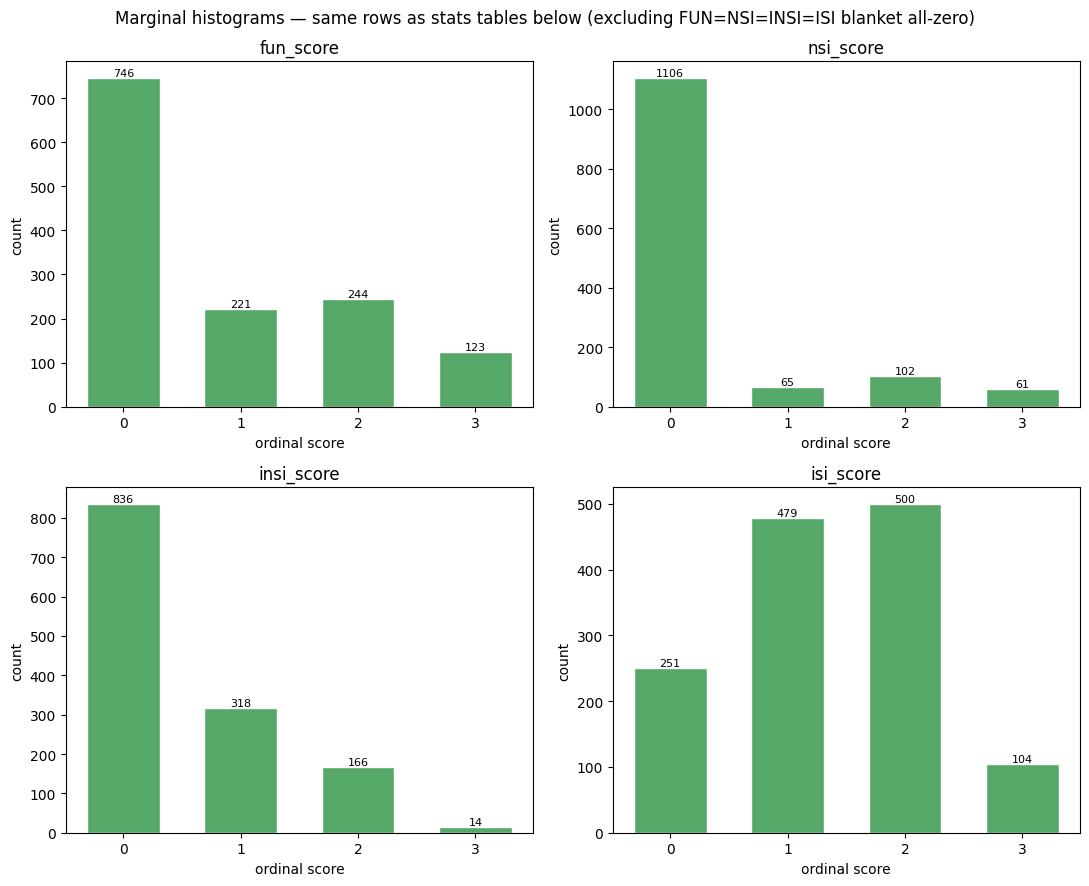

##### Score stats by **repo** — avg/mean = arithmetic average; p50 = sample median (pandas ``median`` / ``quantile(0.5)``).

,repo,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,django/django,709,709,0.978843,0.978843,1.0,0.0,1.0,2.0,3.0,709,0.172073,0.172073,0.0,0.0,0.0,0.0,3.0,709,0.359661,0.359661,0.0,0.0,0.0,1.0,2.0,709,1.51622,1.51622,2.0,1.0,2.0,2.0,3.0
1,expressjs/express,625,625,0.614400,0.614400,0.0,0.0,0.0,1.0,3.0,625,0.528000,0.528000,0.0,0.0,0.0,1.0,3.0,625,0.699200,0.699200,0.0,0.0,0.0,1.0,3.0,625,1.14560,1.14560,1.0,0.0,1.0,2.0,3.0


##### Total score (**FUN+NSI+INSI+ISI**) per judge row — **by repo**

Each row’s **total score** is the sum of the four ordinals (0–12). **sum_total_score** sums those values across rows in each repo.

,repo,n_rows,sum_total_score,mean_total_score,median_total_score,std_total_score
0,django/django,709,2146,3.026798,3.0,1.354262
1,expressjs/express,625,1867,2.987200,3.0,1.365731


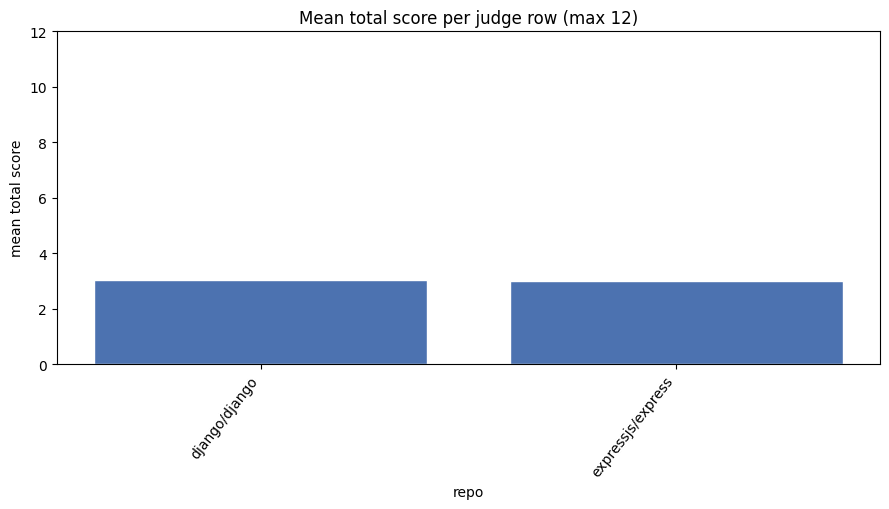

*Repo breakdown: stacked bars = count at ordinal 0/1/2/3 per repo; full-zero judge rows excluded (same scope as global histogram above).*

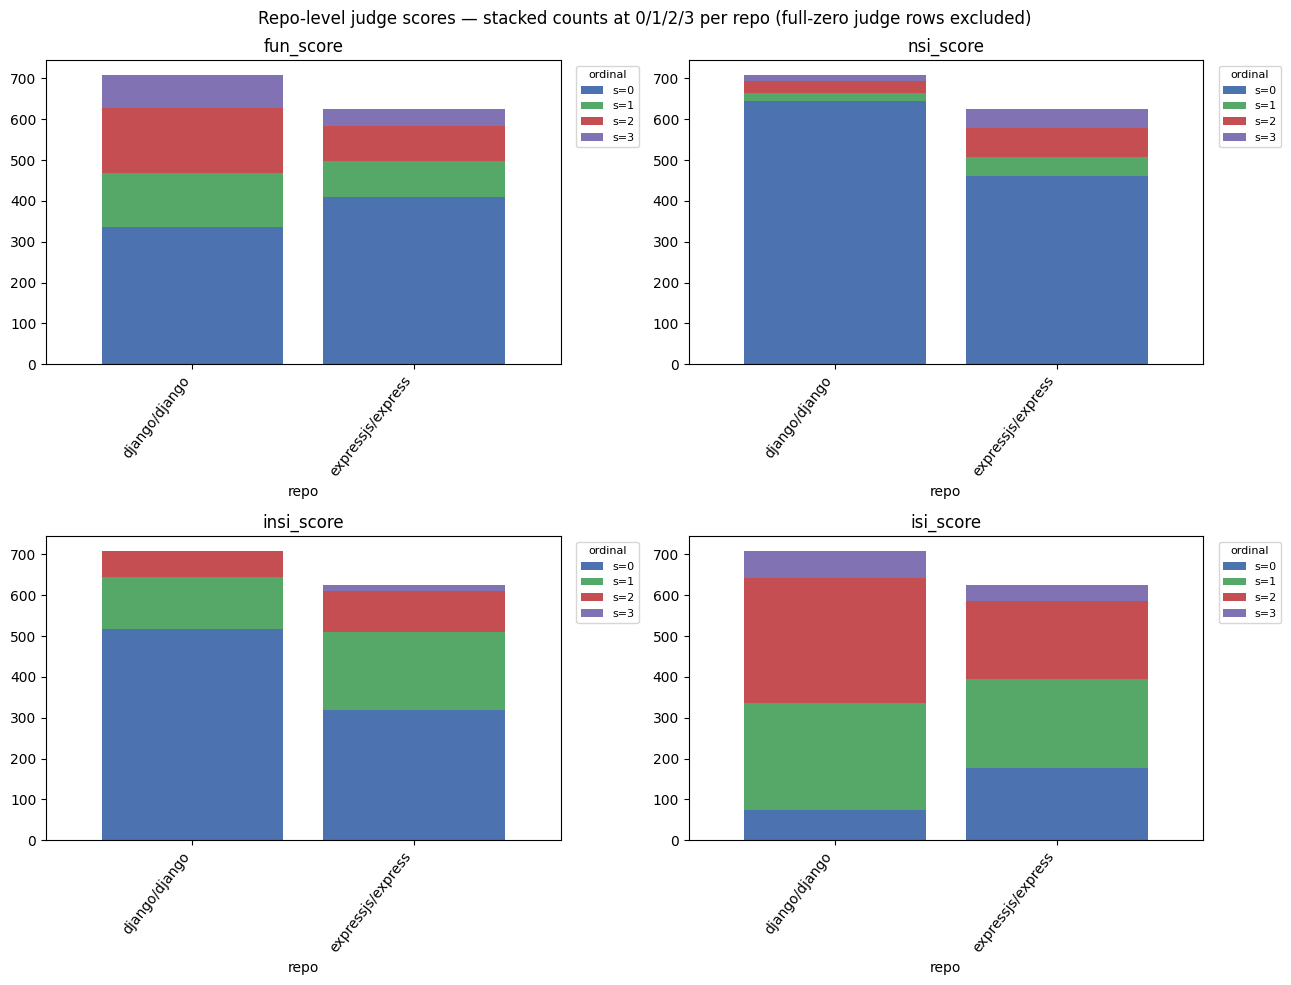

##### Score stats by **repo × author_association**

,repo,author_association,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,django/django,CONTRIBUTOR,182,182,1.104396,1.104396,1.0,0.0,1.0,2.0,3.00,182,0.197802,0.197802,0.0,0.0,0.0,0.0,3.00,182,0.379121,0.379121,0.0,0.0,0.0,1.0,2.0,182,1.527473,1.527473,2.0,1.00,2.0,2.0,3.0
1,django/django,MEMBER,372,372,0.841398,0.841398,0.0,0.0,0.0,2.0,3.00,372,0.212366,0.212366,0.0,0.0,0.0,0.0,3.00,372,0.413978,0.413978,0.0,0.0,0.0,1.0,2.0,372,1.478495,1.478495,2.0,1.00,2.0,2.0,3.0
2,django/django,NONE,155,155,1.161290,1.161290,1.0,0.0,1.0,2.0,3.00,155,0.045161,0.045161,0.0,0.0,0.0,0.0,1.46,155,0.206452,0.206452,0.0,0.0,0.0,0.0,2.0,155,1.593548,1.593548,2.0,1.00,2.0,2.0,3.0
3,expressjs/express,CONTRIBUTOR,4,4,0.500000,0.500000,0.0,0.0,0.0,0.5,1.94,4,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,4,0.500000,0.500000,0.5,0.0,0.5,1.0,1.0,4,1.250000,1.250000,1.5,0.75,1.5,2.0,2.0
4,expressjs/express,MEMBER,335,335,0.600000,0.600000,0.0,0.0,0.0,1.0,3.00,335,0.647761,0.647761,0.0,0.0,0.0,1.0,3.00,335,0.591045,0.591045,0.0,0.0,0.0,1.0,2.0,335,1.283582,1.283582,1.0,1.00,1.0,2.0,3.0
5,expressjs/express,NONE,286,286,0.632867,0.632867,0.0,0.0,0.0,1.0,3.00,286,0.395105,0.395105,0.0,0.0,0.0,0.0,3.00,286,0.828671,0.828671,1.0,0.0,1.0,2.0,3.0,286,0.982517,0.982517,1.0,0.00,1.0,2.0,3.0


##### Score stats by **repo × event type** — top-level ``$.type`` (e.g. ``IssueCommentEvent``, ``PullRequestReviewCommentEvent``)

,repo,event_type,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,django/django,IssueCommentEvent,210,210,0.890476,0.890476,0.0,0.0,0.0,2.0,3.00,210,0.352381,0.352381,0.0,0.0,0.0,0.00,3.00,210,0.423810,0.423810,0.0,0.0,0.0,1.0,2.0,210,1.457143,1.457143,2.0,1.0,2.0,2.0,3.00
1,django/django,PullRequestEvent,194,194,1.510309,1.510309,2.0,1.0,2.0,2.0,3.00,194,0.015464,0.015464,0.0,0.0,0.0,0.00,0.07,194,0.113402,0.113402,0.0,0.0,0.0,0.0,2.0,194,1.649485,1.649485,2.0,1.0,2.0,2.0,3.00
2,django/django,PullRequestReviewCommentEvent,261,261,0.681992,0.681992,0.0,0.0,0.0,1.0,3.00,261,0.114943,0.114943,0.0,0.0,0.0,0.00,2.00,261,0.452107,0.452107,0.0,0.0,0.0,1.0,2.0,261,1.482759,1.482759,2.0,1.0,2.0,2.0,3.00
3,django/django,PullRequestReviewEvent,44,44,0.818182,0.818182,0.0,0.0,0.0,2.0,3.00,44,0.340909,0.340909,0.0,0.0,0.0,0.00,2.57,44,0.590909,0.590909,0.0,0.0,0.0,1.0,2.0,44,1.409091,1.409091,1.0,1.0,1.0,2.0,2.00
4,expressjs/express,IssueCommentEvent,396,396,0.560606,0.560606,0.0,0.0,0.0,1.0,3.00,396,0.699495,0.699495,0.0,0.0,0.0,1.25,3.00,396,0.775253,0.775253,1.0,0.0,1.0,1.0,3.0,396,1.042929,1.042929,1.0,0.0,1.0,2.0,3.00
5,expressjs/express,PullRequestEvent,117,117,0.769231,0.769231,0.0,0.0,0.0,2.0,3.00,117,0.264957,0.264957,0.0,0.0,0.0,0.00,3.00,117,0.470085,0.470085,0.0,0.0,0.0,1.0,2.0,117,1.256410,1.256410,1.0,1.0,1.0,2.0,3.00
6,expressjs/express,PullRequestReviewCommentEvent,80,80,0.687500,0.687500,0.0,0.0,0.0,1.0,3.00,80,0.150000,0.150000,0.0,0.0,0.0,0.00,2.00,80,0.725000,0.725000,1.0,0.0,1.0,1.0,2.0,80,1.450000,1.450000,1.0,1.0,1.0,2.0,3.00
7,expressjs/express,PullRequestReviewEvent,32,32,0.531250,0.531250,0.0,0.0,0.0,1.0,2.69,32,0.312500,0.312500,0.0,0.0,0.0,0.00,2.69,32,0.531250,0.531250,0.0,0.0,0.0,1.0,2.0,32,1.250000,1.250000,1.0,1.0,1.0,2.0,2.69


*Event-type charts (**full** ``$.type`` strings on the y-axis): **four separate figures** in fixed order ``fun_score`` → ``nsi_score`` → ``insi_score`` → ``isi_score`` for saving individually; horizontal stacked bars with tight margins. No plot titles — use the **section heading** above. Full-zero judge rows excluded.*

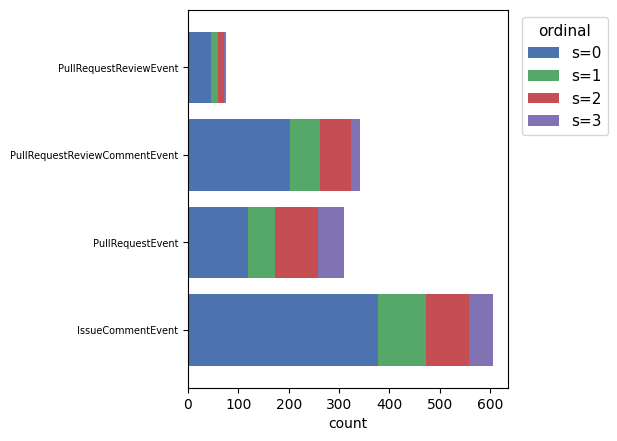

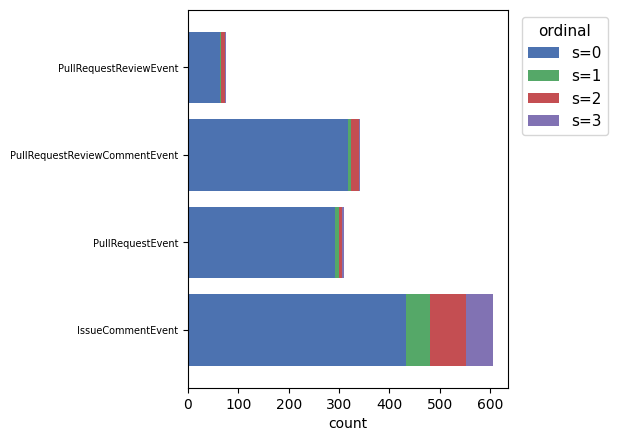

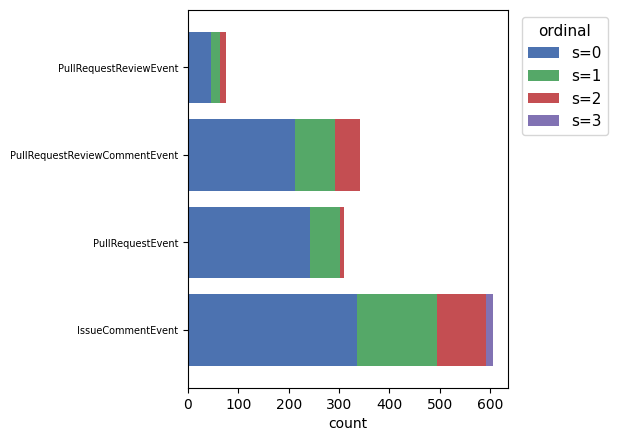

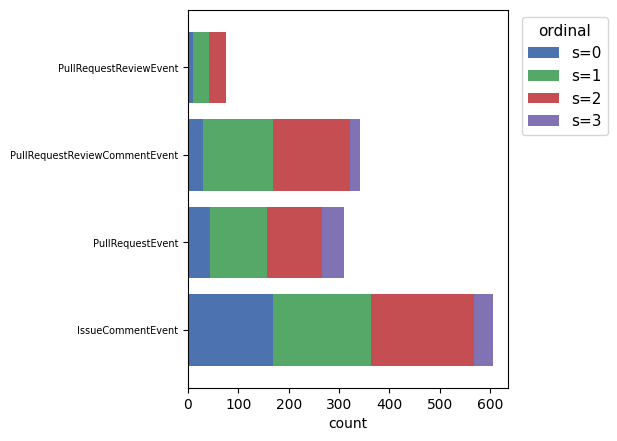

###### Event type — **s = 1, 2, 3** only (same figure order)

Same grouping as above; stacks omit **s = 0**. Four separate plots, no per-figure titles — same section as the first batch.

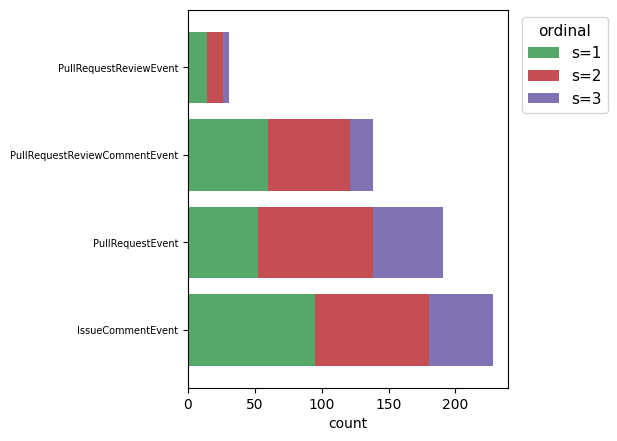

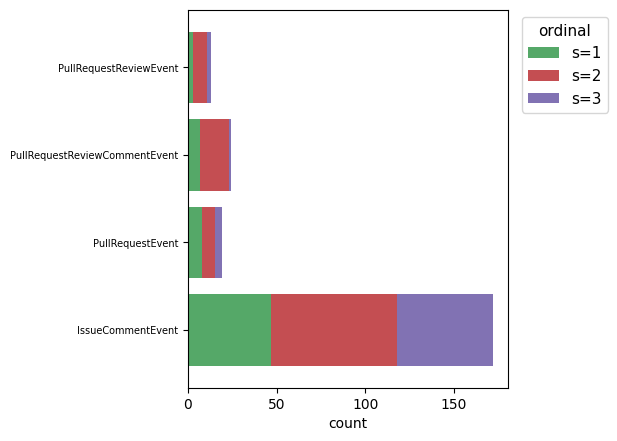

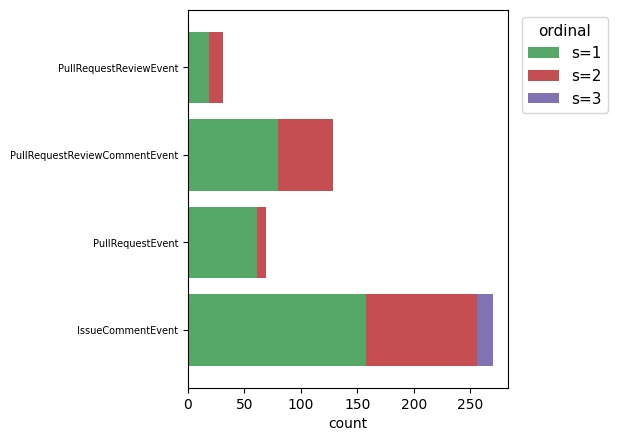

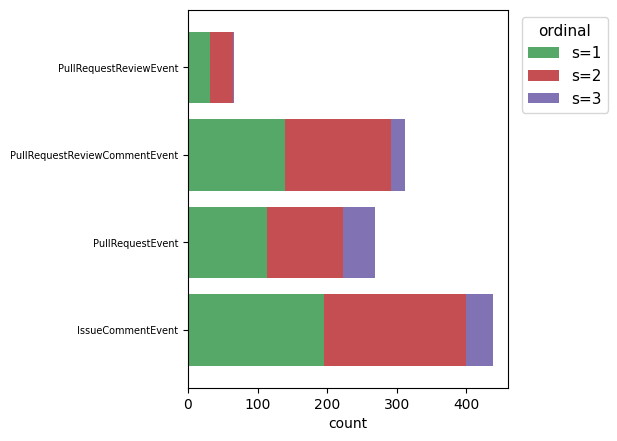

##### Score stats by **repo × author_association × user_login** (``payload.comment.user.login`` / ``review.user.login``, else ``actor.login``)

,repo,author_association,user_login,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,django/django,CONTRIBUTOR,AMK9978,2,2,0.500000,0.500000,0.5,0.25,0.5,0.75,0.99,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,2.000000,2.000000,2.0,2.00,2.0,2.00,2.00
1,django/django,CONTRIBUTOR,HappyDingning,2,2,1.500000,1.500000,1.5,1.25,1.5,1.75,1.99,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,2.000000,2.000000,2.0,2.00,2.0,2.00,2.00
2,django/django,CONTRIBUTOR,Hisham-Pak,1,1,3.000000,3.000000,3.0,3.00,3.0,3.00,3.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
3,django/django,CONTRIBUTOR,LilyFoote,1,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
4,django/django,CONTRIBUTOR,MHLut,1,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,3.000000,3.000000,3.0,3.00,3.0,3.00,3.00
5,django/django,CONTRIBUTOR,Viicos,2,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,0.500000,0.500000,0.5,0.25,0.5,0.75,0.99,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
6,django/django,CONTRIBUTOR,Waheedsys,3,3,1.666667,1.666667,2.0,1.50,2.0,2.00,2.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.333333,0.333333,0.0,0.00,0.0,0.50,0.98,3,1.666667,1.666667,2.0,1.50,2.0,2.00,2.00
7,django/django,CONTRIBUTOR,baidoosik,6,6,0.666667,0.666667,0.5,0.00,0.5,1.00,1.95,6,0.333333,0.333333,0.0,0.00,0.0,0.00,1.90,6,0.500000,0.500000,0.0,0.00,0.0,0.75,1.95,6,1.333333,1.333333,1.5,1.00,1.5,2.00,2.00
8,django/django,CONTRIBUTOR,bcail,4,4,2.000000,2.000000,2.5,1.50,2.5,3.00,3.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,1.250000,1.250000,1.5,0.75,1.5,2.00,2.00
9,django/django,CONTRIBUTOR,dvarrazzo,1,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00


##### Score stats by **repo × author_association × user_login × event type** (top-level ``$.type`` on ``events.event_data``)

,repo,author_association,user_login,event_type,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,django/django,CONTRIBUTOR,AMK9978,PullRequestReviewCommentEvent,2,2,0.500000,0.500000,0.5,0.25,0.5,0.75,0.99,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,2.000000,2.000000,2.0,2.00,2.0,2.00,2.00
1,django/django,CONTRIBUTOR,HappyDingning,PullRequestReviewCommentEvent,2,2,1.500000,1.500000,1.5,1.25,1.5,1.75,1.99,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,2.000000,2.000000,2.0,2.00,2.0,2.00,2.00
2,django/django,CONTRIBUTOR,Hisham-Pak,PullRequestEvent,1,1,3.000000,3.000000,3.0,3.00,3.0,3.00,3.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
3,django/django,CONTRIBUTOR,LilyFoote,PullRequestReviewCommentEvent,1,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
4,django/django,CONTRIBUTOR,MHLut,PullRequestEvent,1,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,3.000000,3.000000,3.0,3.00,3.0,3.00,3.00
5,django/django,CONTRIBUTOR,Viicos,IssueCommentEvent,1,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
6,django/django,CONTRIBUTOR,Viicos,PullRequestEvent,1,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
7,django/django,CONTRIBUTOR,Waheedsys,IssueCommentEvent,2,2,1.500000,1.500000,1.5,1.25,1.5,1.75,1.99,2,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,2,0.500000,0.500000,0.5,0.25,0.5,0.75,0.99,2,2.000000,2.000000,2.0,2.00,2.0,2.00,2.00
8,django/django,CONTRIBUTOR,Waheedsys,PullRequestEvent,1,1,2.000000,2.000000,2.0,2.00,2.0,2.00,2.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,1,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
9,django/django,CONTRIBUTOR,baidoosik,IssueCommentEvent,3,3,0.333333,0.333333,0.0,0.00,0.0,0.50,0.98,3,0.666667,0.666667,0.0,0.00,0.0,1.00,1.96,3,0.666667,0.666667,0.0,0.00,0.0,1.00,1.96,3,1.000000,1.000000,1.0,0.50,1.0,1.50,1.98


In [394]:
# Uncomment only **one** `show_score_stats(...)`: `both` = repo + repo_aa; `repo_type` = repo × $.type; `repo_aa_user_type` = 4-way; `all` runs repo, repo_aa, repo_type, repo_aa_user, repo_aa_user_type.
# show_score_stats()
# show_score_stats("repo")
# show_score_stats("repo_aa")  # aa = author_association
# show_score_stats("repo_aa_user")
# show_score_stats("repo_type")  # repo × event $.type
# show_score_stats("repo_aa_user_type")  # repo × aa × user_login × $.type
# show_score_stats("all")
#show_score_stats("all", exclude_all_zero=True)
show_score_stats("all", exclude_all_zero=True, show_plots=True)  # global histograms + repo & event_type stacked counts
